# 03 — Visualizations

Produces four portfolio-ready charts exported to `outputs/charts/`:
1. Funnel drop-off bar chart
2. Time-to-fill trend line
3. Sourcing channel ROI comparison
4. Recruiter leaderboard

Run notebooks 01 and 02 first.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

CHARTS_DIR = Path("../outputs/charts")
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = "../database/recruitment.db"
conn = sqlite3.connect(DB_PATH)

candidates = pd.read_sql("SELECT * FROM candidates_clean", conn)
pipeline   = pd.read_sql("SELECT * FROM pipeline_stages",  conn)
roles      = pd.read_sql("SELECT * FROM roles",            conn)
clients    = pd.read_sql("SELECT * FROM clients",          conn)

pipeline['stage_date'] = pd.to_datetime(pipeline['stage_date'])
roles['date_opened']   = pd.to_datetime(roles['date_opened'])

pipeline = pipeline.merge(candidates[['candidate_id', 'source_channel']], on='candidate_id', how='left')
roles_ext = roles.merge(clients[['client_id', 'industry']], on='client_id')
pipeline = pipeline.merge(roles_ext[['role_id', 'industry', 'date_opened']], on='role_id', how='left')

STAGE_ORDER = ['Sourced', 'Screened', 'Interviewed', 'Offered', 'Placed']

# Consistent style
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
BRAND_BLUE  = '#2563EB'
BRAND_GREY  = '#94A3B8'

## Chart 1 — Funnel drop-off

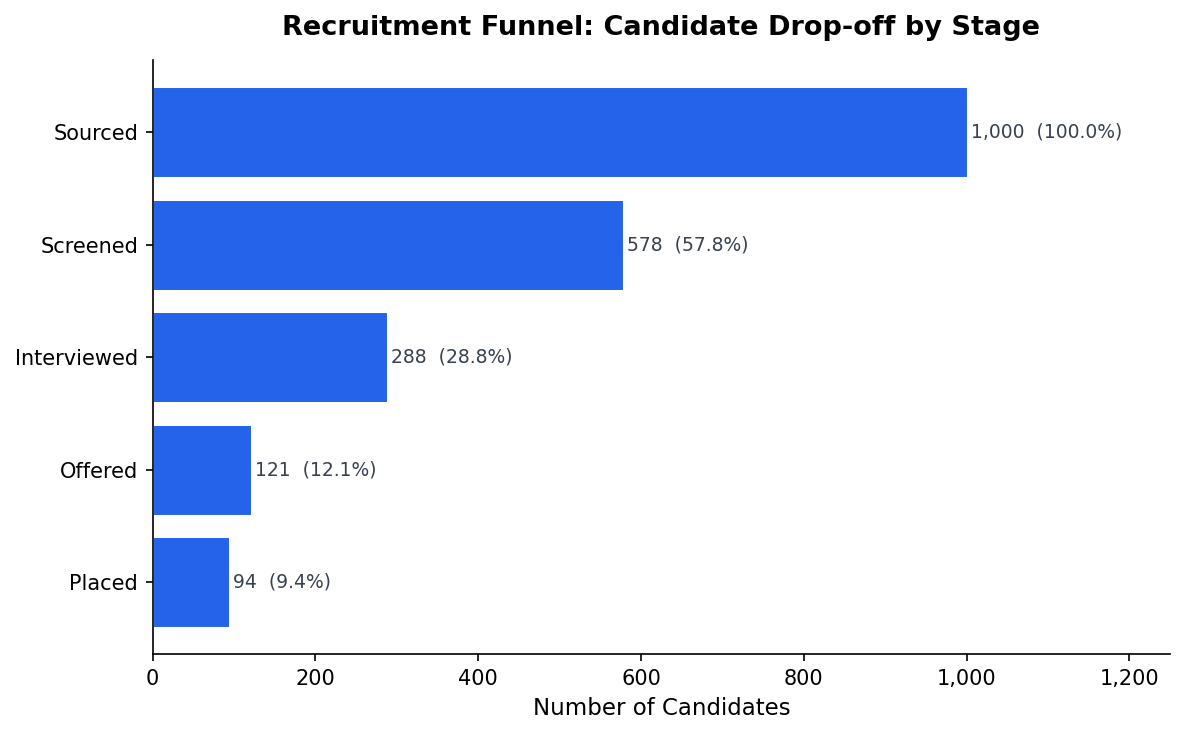

Saved: 01_funnel_dropoff.png


In [2]:
stage_counts = (
    pipeline[pipeline['stage'].isin(STAGE_ORDER)]
    .groupby('stage')['candidate_id'].nunique()
    .reindex(STAGE_ORDER)
)
sourced_n = stage_counts['Sourced']
pct = (stage_counts / sourced_n * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(STAGE_ORDER[::-1], stage_counts.reindex(STAGE_ORDER[::-1]),
               color=BRAND_BLUE, edgecolor='white', linewidth=0.5)

for bar, stage in zip(bars, STAGE_ORDER[::-1]):
    n   = int(stage_counts[stage])
    pct_val = pct[stage]
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{n:,}  ({pct_val}%)', va='center', fontsize=9, color='#374151')

ax.set_xlabel('Number of Candidates')
ax.set_title('Recruitment Funnel: Candidate Drop-off by Stage', fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, sourced_n * 1.25)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '01_funnel_dropoff.png', bbox_inches='tight')
plt.show()
print("Saved: 01_funnel_dropoff.png")

## Chart 2 — Time-to-fill trend

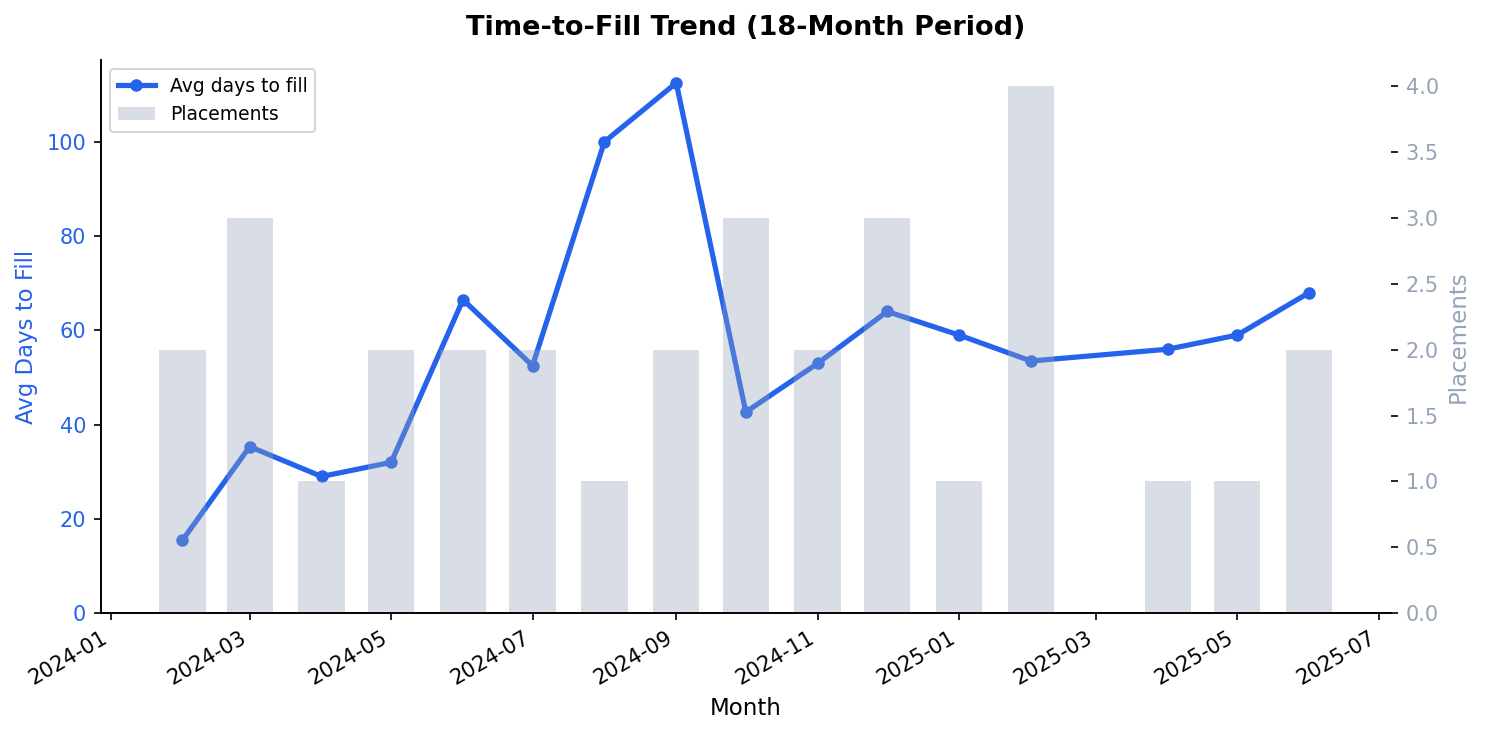

Saved: 02_time_to_fill_trend.png


In [3]:
placed = pipeline[pipeline['stage'] == 'Placed'].copy()
# date_opened already present from the pipeline merge at the top

first_placement = (
    placed.sort_values('stage_date')
    .groupby('role_id')
    .agg(date_placed=('stage_date', 'first'), date_opened=('date_opened', 'first'))
    .reset_index()
)
first_placement['days_to_fill'] = (
    (first_placement['date_placed'] - first_placement['date_opened']).dt.days
    .clip(lower=1)
)
first_placement['month'] = first_placement['date_placed'].dt.to_period('M')

monthly = (
    first_placement.groupby('month')
    .agg(avg_days=('days_to_fill', 'mean'), placements=('role_id', 'count'))
    .reset_index()
)
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(monthly['month_dt'], monthly['avg_days'], color=BRAND_BLUE,
         linewidth=2.5, marker='o', markersize=5, label='Avg days to fill')
ax2.bar(monthly['month_dt'], monthly['placements'], width=20,
        color=BRAND_GREY, alpha=0.35, label='Placements')

ax1.set_xlabel('Month')
ax1.set_ylabel('Avg Days to Fill', color=BRAND_BLUE)
ax2.set_ylabel('Placements', color=BRAND_GREY)
ax1.tick_params(axis='y', labelcolor=BRAND_BLUE)
ax2.tick_params(axis='y', labelcolor=BRAND_GREY)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.set_title('Time-to-Fill Trend (18-Month Period)', fontweight='bold', pad=12)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(CHARTS_DIR / '02_time_to_fill_trend.png', bbox_inches='tight')
plt.show()
print("Saved: 02_time_to_fill_trend.png")


## Chart 3 — Sourcing channel ROI

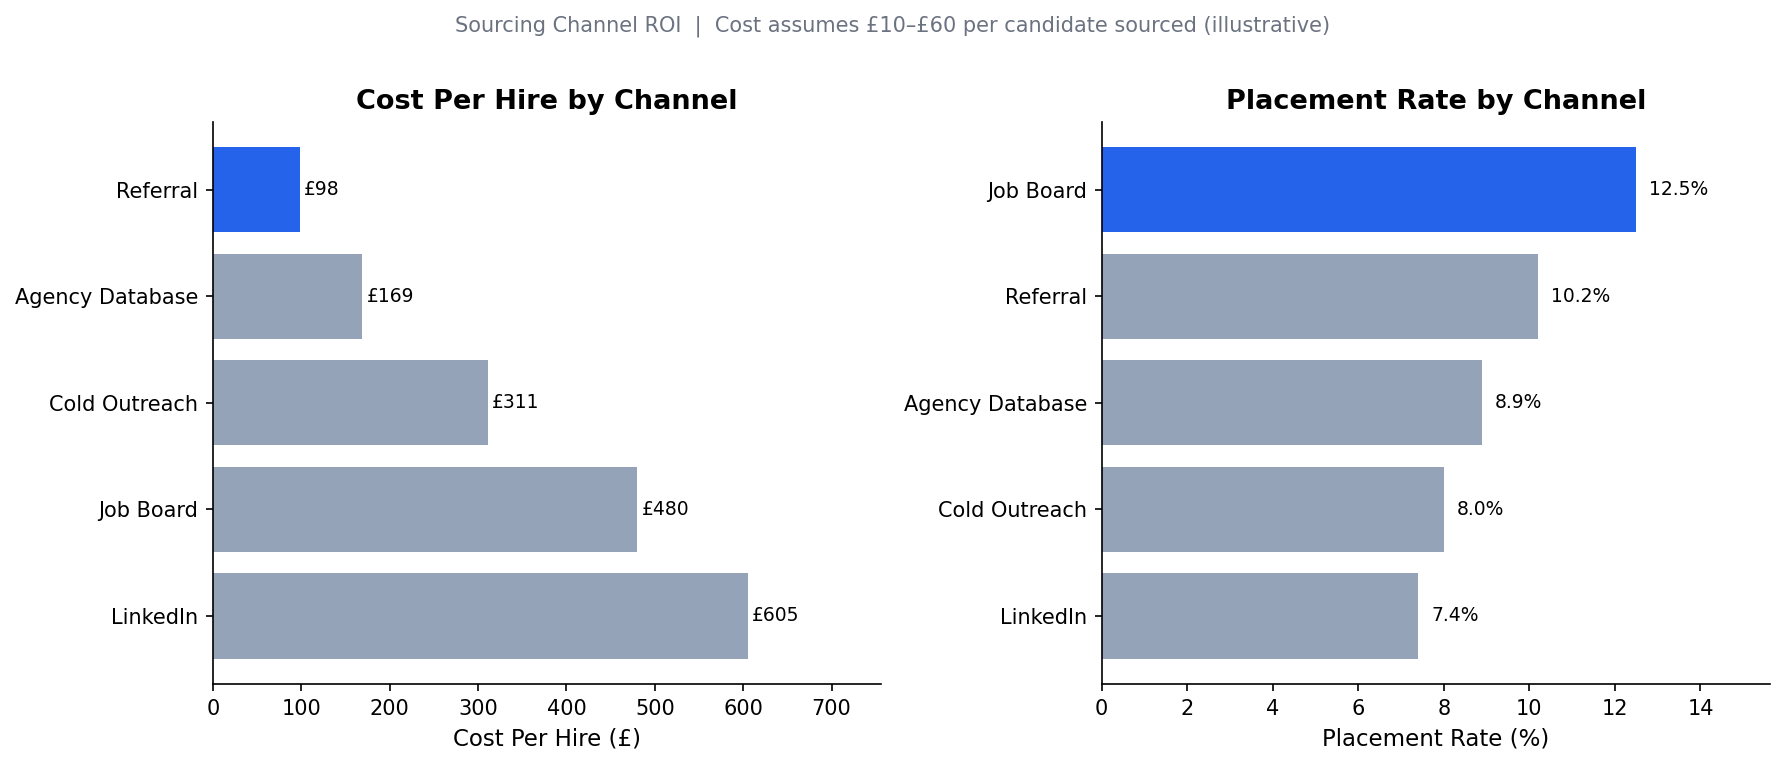

Saved: 03_sourcing_roi.png


In [4]:
CHANNEL_COST = {
    'LinkedIn': 45, 'Referral': 10, 'Job Board': 60,
    'Agency Database': 15, 'Cold Outreach': 25,
}

ch = (
    pipeline[pipeline['stage'].isin(['Sourced', 'Placed'])]
    .groupby(['source_channel', 'stage'])['candidate_id']
    .nunique().unstack(fill_value=0)
)
if 'Placed' not in ch.columns:
    ch['Placed'] = 0

ch['cost_per_sourced'] = ch.index.map(CHANNEL_COST)
ch['total_spend']      = ch['Sourced'] * ch['cost_per_sourced']
ch['cost_per_hire']    = (ch['total_spend'] / ch['Placed']).round(0)
ch['placement_rate']   = (ch['Placed'] / ch['Sourced'] * 100).round(1)
ch = ch.sort_values('cost_per_hire')

colours = [BRAND_BLUE if c == ch['cost_per_hire'].min() else BRAND_GREY for c in ch['cost_per_hire']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: cost per hire
axes[0].barh(ch.index, ch['cost_per_hire'], color=colours)
for i, (val, idx) in enumerate(zip(ch['cost_per_hire'], ch.index)):
    axes[0].text(val + 5, i, f'£{int(val):,}', va='center', fontsize=9)
axes[0].set_xlabel('Cost Per Hire (£)')
axes[0].set_title('Cost Per Hire by Channel', fontweight='bold')
axes[0].set_xlim(0, ch['cost_per_hire'].max() * 1.25)
axes[0].invert_yaxis()

# Right: placement rate
ch2 = ch.sort_values('placement_rate', ascending=False)
colours2 = [BRAND_BLUE if c == ch2['placement_rate'].max() else BRAND_GREY for c in ch2['placement_rate']]
axes[1].barh(ch2.index, ch2['placement_rate'], color=colours2)
for i, (val, idx) in enumerate(zip(ch2['placement_rate'], ch2.index)):
    axes[1].text(val + 0.3, i, f'{val}%', va='center', fontsize=9)
axes[1].set_xlabel('Placement Rate (%)')
axes[1].set_title('Placement Rate by Channel', fontweight='bold')
axes[1].set_xlim(0, ch2['placement_rate'].max() * 1.25)
axes[1].invert_yaxis()

fig.suptitle('Sourcing Channel ROI  |  Cost assumes £10–£60 per candidate sourced (illustrative)',
             fontsize=10, color='#6B7280', y=1.01)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '03_sourcing_roi.png', bbox_inches='tight')
plt.show()
print("Saved: 03_sourcing_roi.png")

## Chart 4 — Recruiter leaderboard

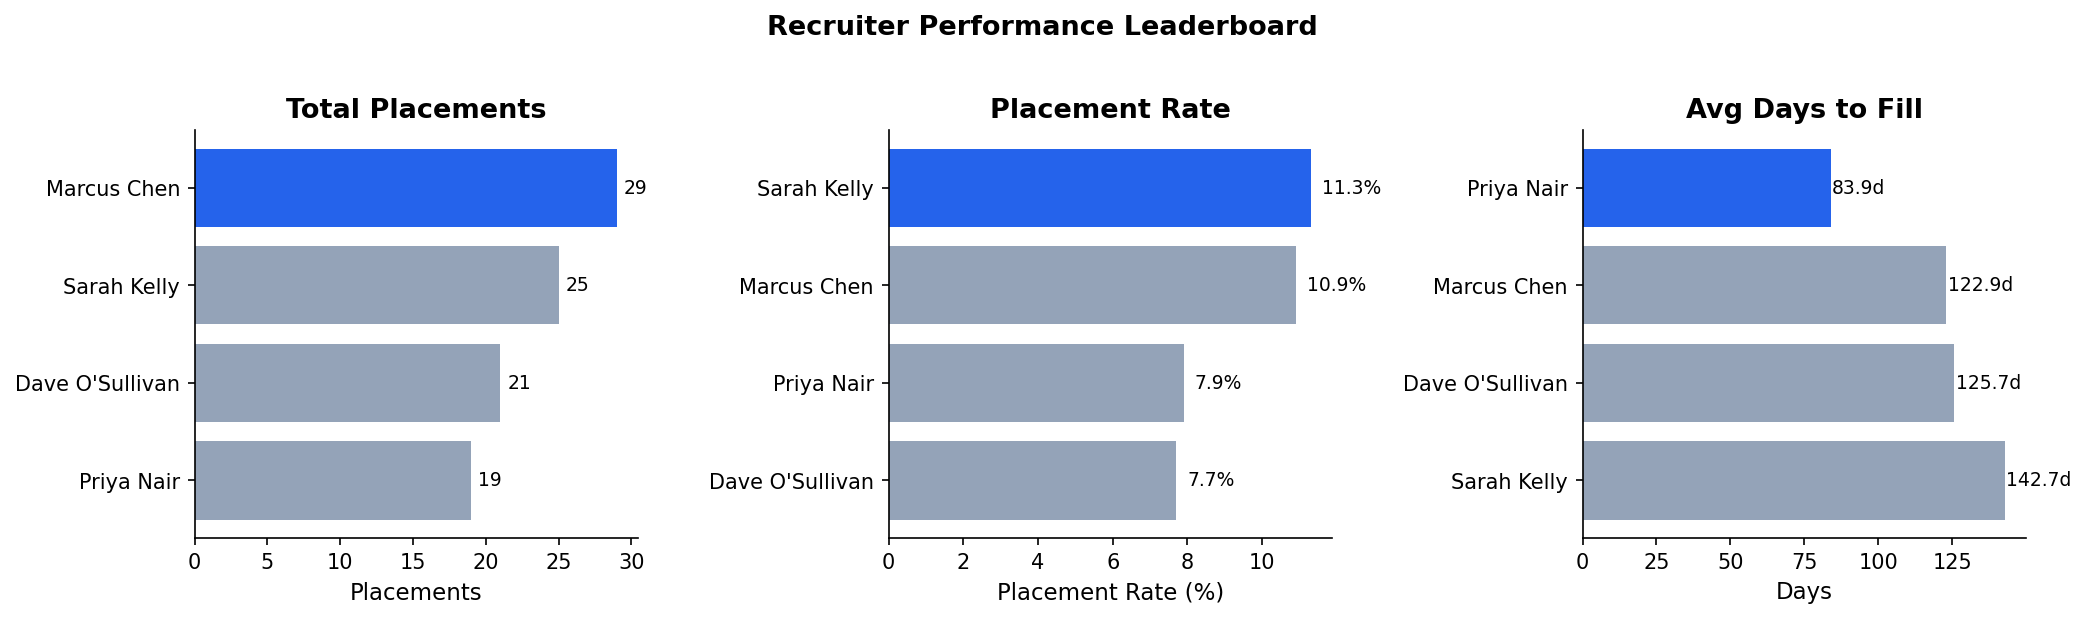

Saved: 04_recruiter_leaderboard.png


In [5]:
r_sourced = (
    pipeline[pipeline['stage'] == 'Sourced']
    .groupby('recruiter')['candidate_id'].nunique().rename('sourced')
)
r_placed = (
    pipeline[pipeline['stage'] == 'Placed']
    .groupby('recruiter')['candidate_id'].nunique().rename('placed')
)
sc = pd.concat([r_sourced, r_placed], axis=1).fillna(0)
sc['placement_rate'] = (sc['placed'] / sc['sourced'] * 100).round(1)

placed_ext = placed.copy()
placed_ext['days_to_fill'] = (placed_ext['stage_date'] - placed_ext['date_opened']).dt.days
r_ttf = placed_ext.groupby('recruiter')['days_to_fill'].mean().round(1).rename('avg_days_to_fill')
sc = sc.join(r_ttf)
sc = sc.sort_values('placed', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

top_placer = sc['placed'].idxmax()
colours_p = [BRAND_BLUE if r == top_placer else BRAND_GREY for r in sc.index]

axes[0].barh(sc.index, sc['placed'], color=colours_p)
for i, (val, idx) in enumerate(zip(sc['placed'], sc.index)):
    axes[0].text(val + 0.5, i, str(int(val)), va='center', fontsize=9)
axes[0].set_title('Total Placements', fontweight='bold')
axes[0].set_xlabel('Placements')

sc2 = sc.sort_values('placement_rate', ascending=True)
top_rate = sc2['placement_rate'].idxmax()
colours_r = [BRAND_BLUE if r == top_rate else BRAND_GREY for r in sc2.index]
axes[1].barh(sc2.index, sc2['placement_rate'], color=colours_r)
for i, (val, idx) in enumerate(zip(sc2['placement_rate'], sc2.index)):
    axes[1].text(val + 0.3, i, f'{val}%', va='center', fontsize=9)
axes[1].set_title('Placement Rate', fontweight='bold')
axes[1].set_xlabel('Placement Rate (%)')

sc3 = sc.sort_values('avg_days_to_fill', ascending=False)
best_ttf = sc3['avg_days_to_fill'].idxmin()
colours_t = [BRAND_BLUE if r == best_ttf else BRAND_GREY for r in sc3.index]
axes[2].barh(sc3.index, sc3['avg_days_to_fill'], color=colours_t)
for i, (val, idx) in enumerate(zip(sc3['avg_days_to_fill'], sc3.index)):
    axes[2].text(val + 0.5, i, f'{val}d', va='center', fontsize=9)
axes[2].set_title('Avg Days to Fill', fontweight='bold')
axes[2].set_xlabel('Days')

fig.suptitle('Recruiter Performance Leaderboard', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '04_recruiter_leaderboard.png', bbox_inches='tight')
plt.show()
print("Saved: 04_recruiter_leaderboard.png")

## Chart 5 — Conversion rate heatmap by channel

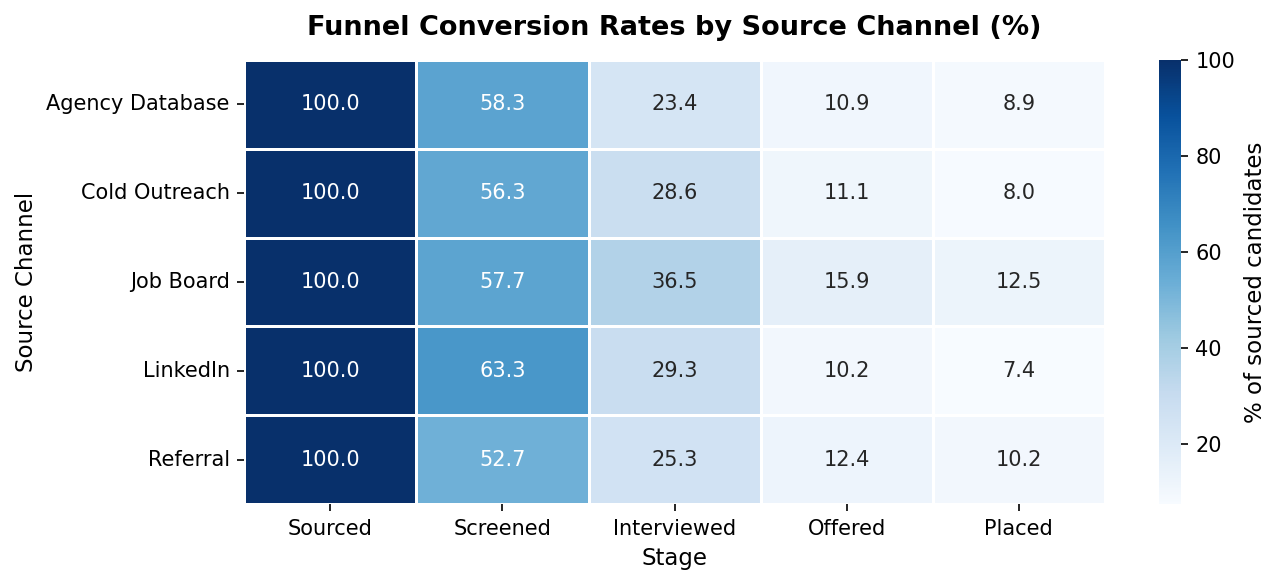

Saved: 05_channel_heatmap.png


In [6]:
heatmap_data = (
    pipeline[pipeline['stage'].isin(STAGE_ORDER)]
    .groupby(['source_channel', 'stage'])['candidate_id']
    .nunique().unstack(fill_value=0)
    .reindex(columns=STAGE_ORDER, fill_value=0)
)
# Convert to % of sourced for that channel
heatmap_pct = heatmap_data.div(heatmap_data['Sourced'], axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heatmap_pct.round(1), annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': '% of sourced candidates'}, ax=ax)
ax.set_title('Funnel Conversion Rates by Source Channel (%)', fontweight='bold', pad=12)
ax.set_xlabel('Stage')
ax.set_ylabel('Source Channel')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '05_channel_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: 05_channel_heatmap.png")
conn.close()